# 001 EDA Credit Card Fraud

## Header

In [3]:
from notebook_config import setup

In [4]:
import io
import pandas as pd
import matplotlib.pyplot as plt

from config import settings

from src.ingestion.upload_dataset import BUCKET_KEY
from src.utils.s3_client import get_s3_client

## Dataset: Credit Card Fraud

In [5]:
bucket = settings.MINIO_BUCKET
key = BUCKET_KEY

s3 = get_s3_client()
obj = s3.get_object(Bucket=bucket, Key=BUCKET_KEY)
payload = obj['Body'].read()

df = pd.read_csv(io.BytesIO(payload))
df.head()

2026-05-01 17:04:35 | INFO | src.utils.s3_client | Creating S3 client with endpoint: http://localhost:9000
2026-05-01 17:04:35 | INFO | src.utils.s3_client | S3 client created successfully


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


`Time`: Tempo em segundos (s) desde a primeira transação do dataset.  
`V1` -> `V28`: Features geradas a partir de PCA.  
`Amount`: Valor da transação.  
`Class`: Target, variável de resposta (0 -> Transação normal, 1 -> Fraude).  

In [6]:
missing = df.isna().sum()
missing_ratio = (missing / len(df) * 100).round(4)
pd.DataFrame({'missing': missing, 'missing_pct': missing_ratio}).sort_values('missing', ascending=False).head(10)

,missing,missing_pct
Time,0,0.0000
V1,0,0.0000
V2,0,0.0000
V3,0,0.0000
V4,0,0.0000
V5,0,0.0000
V6,0,0.0000
V7,0,0.0000
V8,0,0.0000
V9,0,0.0000


Dataset sem dados faltantes.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,"284,807.0000","94,813.8596","47,488.1460",0.0000,"54,201.5000","84,692.0000","139,320.5000","172,792.0000"
V1,"284,807.0000",0.0000,1.9587,-56.4075,-0.9204,0.0181,1.3156,2.4549
V2,"284,807.0000",0.0000,1.6513,-72.7157,-0.5985,0.0655,0.8037,22.0577
V3,"284,807.0000",-0.0000,1.5163,-48.3256,-0.8904,0.1798,1.0272,9.3826
V4,"284,807.0000",0.0000,1.4159,-5.6832,-0.8486,-0.0198,0.7433,16.8753
V5,"284,807.0000",0.0000,1.3802,-113.7433,-0.6916,-0.0543,0.6119,34.8017
V6,"284,807.0000",0.0000,1.3323,-26.1605,-0.7683,-0.2742,0.3986,73.3016
V7,"284,807.0000",-0.0000,1.2371,-43.5572,-0.5541,0.0401,0.5704,120.5895
V8,"284,807.0000",0.0000,1.1944,-73.2167,-0.2086,0.0224,0.3273,20.0072
V9,"284,807.0000",-0.0000,1.0986,-13.4341,-0.6431,-0.0514,0.5971,15.5950


Describe pivotado para linhas sendo as features e as colunas sendo os valores.

In [8]:
class_counts = df['Class'].value_counts().sort_index()
class_pct = (class_counts / class_counts.sum() * 100).round(4)
pd.DataFrame({'count': class_counts, 'pct': class_pct})

,count,pct
Class,,
0,284315,99.8273
1,492,0.1727


Desbalanceamento de classes. Fraudes são eventos raros que acontecem apenas 0.17% das vezes.

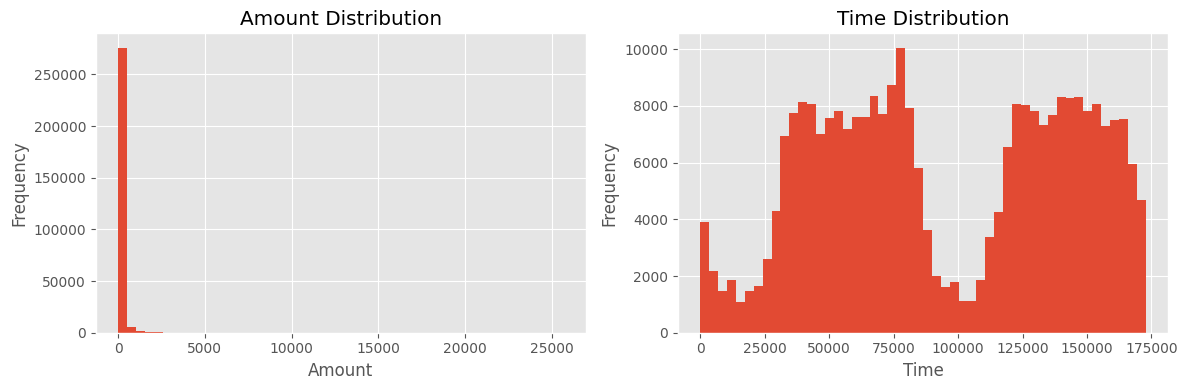

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Amount'].plot(kind='hist', bins=50, ax=axes[0], title='Amount Distribution')
axes[0].set_xlabel('Amount')
df['Time'].plot(kind='hist', bins=50, ax=axes[1], title='Time Distribution')
axes[1].set_xlabel('Time')
plt.tight_layout()
plt.show()

`Amount` representa uma distribuição altamente assimétrica, com cauda longa até valores muitos altos. Se tratando de uma distribuição assimétrica (Skewed).

`Time` apresenta uma distribuição mais esparça, com comportamento ondulado, com horário com mais e menos atividade.

In [10]:
corr_cols = ['Amount', 'Time', 'Class']
corr = df[corr_cols].corr()
corr

,Amount,Time,Class
Amount,1.0000,-0.0106,0.0056
Time,-0.0106,1.0000,-0.0123
Class,0.0056,-0.0123,1.0000
